# Weeks 5–8 Consolidation Practical (Solutions)

This notebook contains example solutions for `09_practical_STUDENT.ipynb`. As with previous
weeks, there is often more than one valid way to solve these problems — if your code produces
the correct result via a different route, that's fine!

---


## Section 1: `numpy.ndarray` fundamentals (Week 5)

In [1]:
import numpy as np

### Exercise 1.1

In [2]:
data = np.arange(1, 21, dtype=np.int32)
print(data.shape, data.dtype)

data_slice = data[:5]
data_slice[0] = -1

print(data)
# data changed because a slice of a numpy array is a VIEW onto the same
# underlying memory, not a copy (unlike slicing a python list).


(20,) int32
[-1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


### Exercise 1.2

In [3]:
def winsorize(data, cut_off=0.1):
    """
    Winsorize a numpy.ndarray in place.

    Parameters:
    -----------
    data: numpy.ndarray
        numeric data to winsorize (modified in place)
    cut_off: float
        proportion to winsorize at each tail (default 0.1 -> 10th/90th percentiles)
    """
    low = np.percentile(data, cut_off * 100)
    high = np.percentile(data, (1 - cut_off) * 100)

    data[np.where(data < low)] = low
    data[np.where(data > high)] = high


data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
winsorize(data)
print(data)


[ 2  2  3  4  5  6  7  8  9 10 10]


## Section 2: Statistical procedures in `numpy` (Week 6)

### Exercise 2.1

In [4]:
SAMPLE_SIZE = 10_000

rng = np.random.default_rng(42)
samples = rng.normal(size=SAMPLE_SIZE)


def basic_descriptives(data):
    """
    Returns mean, stdev, and 1st and 99th percentile of a 1D numpy.ndarray

    Parameters:
    ------------
    data: numpy.ndarray
        numeric data to analyse

    Returns:
    --------
    (float, float, float, float)
    """
    mean = data.mean()
    std = data.std()
    per_1st = np.percentile(data, 1)
    per_99th = np.percentile(data, 99)

    return mean, std, per_1st, per_99th


results = basic_descriptives(samples)
print(results)


(np.float64(-0.010249875414011648), np.float64(1.006285768537041), np.float64(-2.3738111979173713), np.float64(2.3558409670159173))


### Exercise 2.2

In [5]:
def prob_great_than_or_equal_to(data, x):
    """Return the proportion of the dataset that is greater than or equal to x"""
    return (data >= x).sum() / data.shape[0]


def prob_less_than_or_equal_to(data, x):
    """Return the proportion of the dataset that is less than or equal to x"""
    return (data <= x).sum() / data.shape[0]


p_upper = prob_great_than_or_equal_to(samples, 1.96)
p_lower = prob_less_than_or_equal_to(samples, -1.96)

print('P(X >= 1.96):', p_upper)
print('P(X <= -1.96):', p_lower)
print('P(-1.96 < X < 1.96):', 1 - (p_upper + p_lower))
# This is close to the expected ~95% for a standard normal distribution.


P(X >= 1.96): 0.0257
P(X <= -1.96): 0.0257
P(-1.96 < X < 1.96): 0.9486


## Section 3: `pandas.DataFrame` basics and filtering (Week 7)

In [6]:
import pandas as pd

### Exercise 3.1

In [7]:
unique_patient_id = ['het1m', 'ulr33f', 'ham1f', 'tru4m']
surname = ['Hetfield', 'Ulrich', 'Hammett', 'Trujillo']
age = [50, 89, 32, 65]
female = [False, True, True, False]
first_appointment = [False, True, True, True]

patient_bookings = pd.DataFrame()
patient_bookings['unique_id'] = pd.Series(unique_patient_id, dtype=str)
patient_bookings['surname'] = pd.Series(surname, dtype=str)
patient_bookings['age'] = pd.Series(age, dtype=np.uint8)
patient_bookings['female'] = pd.Series(female, dtype=bool)
patient_bookings['first_appoint'] = pd.Series(first_appointment, dtype=bool)

patient_bookings = patient_bookings.set_index('unique_id')
patient_bookings


,surname,age,female,first_appoint
unique_id,,,,
het1m,Hetfield,50,False,False
ulr33f,Ulrich,89,True,True
ham1f,Hammett,32,True,True
tru4m,Trujillo,65,False,True


In [8]:
# filter for index 'ham1f'
patient_bookings.loc['ham1f']


surname          Hammett
age                   32
female              True
first_appoint       True
Name: ham1f, dtype: object

In [9]:
# filter for both 'tru4m' and 'ulr33f'
to_find = ['tru4m', 'ulr33f']
patient_bookings.loc[to_find]


,surname,age,female,first_appoint
unique_id,,,,
tru4m,Trujillo,65,False,True
ulr33f,Ulrich,89,True,True


### Exercise 3.2

In [10]:
DATA_URL = ('https://raw.githubusercontent.com/health-data-science-OR/'
            'hpdm139-datasets/main/sw_imaging.csv')

sw_imaging = pd.read_csv(DATA_URL)
sw_imaging.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region        31 non-null     object 
 1   org_code      31 non-null     object 
 2   provider      31 non-null     object 
 3   imaging_type  31 non-null     object 
 4   n_referrals   31 non-null     int64  
 5   mdn_days_rtt  31 non-null     float64
 6   mdn_days_ttr  31 non-null     float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ KB


In [11]:
print(sw_imaging.shape)
sw_imaging.head(2)


(31, 7)


,region,org_code,provider,imaging_type,n_referrals,mdn_days_rtt,mdn_days_ttr
0,Y58,REF,Royal Cornwall Hospitals NHS Trust,Computerized Axial Tomography,46160,3.0,0.0
1,Y58,REF,Royal Cornwall Hospitals NHS Trust,Diagnostic Ultrasonography,72985,14.0,0.0


In [12]:
# only Magnetic Resonance Imaging
sw_imaging[sw_imaging['imaging_type'] == 'Magnetic Resonance Imaging']


,region,org_code,provider,imaging_type,n_referrals,mdn_days_rtt,mdn_days_ttr
3,Y58,REF,Royal Cornwall Hospitals NHS Trust,Magnetic Resonance Imaging,27535,40.0,5.0
10,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Magnetic Resonance Imaging,22380,23.0,7.0
18,Y58,RA9,Torbay and South Devon NHS Foundation Trust,Magnetic Resonance Imaging,14730,14.0,2.0
26,Y58,RK9,University Hospitals Plymouth NHS Trust,Magnetic Resonance Imaging,27210,30.0,3.0


In [13]:
# only the Royal Devon and Exeter NHS Foundation Trust
sw_imaging[sw_imaging['provider'] == 'Royal Devon and Exeter NHS Foundation Trust']


,region,org_code,provider,imaging_type,n_referrals,mdn_days_rtt,mdn_days_ttr
7,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Computerized Axial Tomography,40870,3.0,0.0
8,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Diagnostic Ultrasonography,40070,14.0,0.0
9,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Fluoroscopy,4745,16.0,0.0
10,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Magnetic Resonance Imaging,22380,23.0,7.0
11,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Nuclear Medicine Procedure,3465,14.0,1.0
12,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Plain Radiography,161850,0.0,1.0
13,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Positron Emission Tomography,1000,9.0,4.0
14,Y58,RH8,Royal Devon and Exeter NHS Foundation Trust,Single Photon Emission Computerized Tomography,545,17.0,2.0


In [14]:
# n_referrals > 100,000 AND mdn_days_rtt > 0
sw_imaging[(sw_imaging['n_referrals'] > 100_000) &
           (sw_imaging['mdn_days_rtt'] > 0)]


,region,org_code,provider,imaging_type,n_referrals,mdn_days_rtt,mdn_days_ttr


### Exercise 3.3

In [15]:
results = sw_imaging.groupby(by='provider')['n_referrals'].sum()
results


provider
Royal Cornwall Hospitals NHS Trust             361965
Royal Devon and Exeter NHS Foundation Trust    274925
Torbay and South Devon NHS Foundation Trust    210195
University Hospitals Plymouth NHS Trust        377860
Name: n_referrals, dtype: int64

In [16]:
# save the results
results.to_csv('total_referrals.csv', index=True)


In [17]:
# provider with the highest number of referrals
results[results == results.max()]


provider
University Hospitals Plymouth NHS Trust    377860
Name: n_referrals, dtype: int64

## Section 4: Data wrangling and `matplotlib` (Week 8)

In [18]:
import matplotlib.pyplot as plt

### Exercise 4.1

In [19]:
LONG_URL = ('https://raw.githubusercontent.com/health-data-science-OR/'
            'hpdm139-datasets/main/syn_ts_ed_long.csv')

long_df = pd.read_csv(LONG_URL)
long_df.head()


,date,hosp,attends
0,2014-04-01,1,331
1,2014-04-02,1,340
2,2014-04-03,1,316
3,2014-04-04,1,304
4,2014-04-05,1,292


In [20]:
long_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date     1100 non-null   object
 1   hosp     1100 non-null   int64 
 2   attends  1100 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 25.9+ KB


In [21]:
def ed_data_to_wide(filepath):
    """
    Return the ED data in wide format.

    1. Pivot table
    2. Transpose and drop the (attends, hosp_i) multi-index
    3. Rename columns 0, 1, 2, 3 to hosp1, hosp2, hosp3, hosp4
    4. Index to DateTimeIndex
    5. Convert attendance numbers from int64 to int16

    Params:
    -------
    filepath: str
        Path to long format file

    Returns:
    --------
    pandas.DataFrame
    """
    translated_names = {0: 'hosp1', 1: 'hosp2', 2: 'hosp3', 3: 'hosp4'}
    dtypes = {'hosp1': np.int16, 'hosp2': np.int16, 'hosp3': np.int16, 'hosp4': np.int16}

    df = (pd.read_csv(filepath)
          .pivot_table(values='attends', index='date', columns='hosp')
          .T.reset_index(drop=True).T
          .rename(columns=translated_names)
          .assign(date=lambda x: pd.to_datetime(x.index))
          .set_index('date')
          .astype(dtypes))

    return df


wide_df = ed_data_to_wide(LONG_URL)
wide_df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 275 entries, 2014-04-01 to 2014-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   hosp1   275 non-null    int16
 1   hosp2   275 non-null    int16
 2   hosp3   275 non-null    int16
 3   hosp4   275 non-null    int16
dtypes: int16(4)
memory usage: 4.3 KB


In [22]:
wide_df.head()

,hosp1,hosp2,hosp3,hosp4
date,,,,
2014-04-01,331,287,195,184
2014-04-02,340,293,177,181
2014-04-03,316,249,183,192
2014-04-04,304,313,208,157
2014-04-05,292,291,218,166


### Exercise 4.2

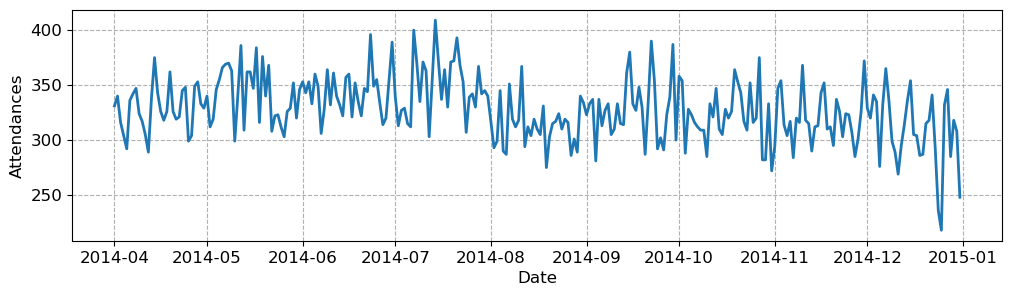

In [23]:
fig = plt.figure(figsize=(12, 3))
ax = fig.add_subplot()

ax.plot(wide_df['hosp1'], lw=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Attendances', fontsize=12)
ax.grid(ls='--')
ax.tick_params(axis='both', labelsize=12)

fig.savefig('hosp1_ed.png', dpi=300)
plt.show()


---
## End of consolidation practical solutions